In [41]:
import numpy as np 
import Physical_Const as phys
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import brentq
from scipy.integrate import ode, odeint


import WD.neutrinos as nunu
import WD.CarbonFusion as eCC
import WD.EoS_ionee as EOS
import WD.ion_electron as ionee
import WD.ions as ion
import WD.electron_electron as ee
import WD.Cv_star as cv


#----Constants------

hbar     = phys.hbar
c        = phys.c
G        = phys.G
sigma    = phys.sigmaSB
me_mev   = phys.me
e        = phys.e
e_erg    = phys.e_erg
mevtoerg = phys.mevtoerg
mu       = phys.mu
kappaB   = phys.kappa
Msun     = phys.Msun
Rsun     = phys.Rsun

h        = hbar*(2.0*np.pi)
me       = me_mev * mevtoerg / c**2
c2       = c*c
arad     = 4.0*sigma / c
Tr       = me * c2 / kappaB
pi05     = np.sqrt(np.pi)
RBohr    = hbar**2 / (me*e_erg)
yr       = (364)*24*60*60
avo      = 1.0/mu


# ---Dimensions---
MA       = 2.0
Cgrav    = G * Msun / c**2
mpl      = np.sqrt(hbar * c / G) # planck mass
Rdim     = np.power( mpl / me , 2.0) * hbar / (mpl * c)
Sigma02  = np.power( c / Rdim,2.0) / G

Sigma    = np.power(me,4.0)*np.power(c,3.0)/(8.0*np.power(np.pi,2.0)*np.power(hbar,3.0))
SigmaP   = c**2 * Sigma
#Sigma02  = ( mu * MA * np.power(me*c/hbar,3) ) / (3 *np.power(np.pi,2))
#Rdim     = c / np.sqrt( Sigma02 * G )
Mdim     = Rdim / Cgrav

Jdim     = G / c**3
Jadim    = 1e50
JJdim    = Jadim * Jdim  / Rdim**2

Tdim     = np.power(c**5 / ( 16.0**2 * np.pi**2 * G * sigma * Rsun**2) ,1.0/4.0)

rhobeta  = np.log10(3.9e10)

In [2]:
#---Algoritm first derivativa----------
def factorD(x,x0,x1,x2,x3):
    den = 3.0 * x * x - 2.0 * x * ( x1 + x2 + x3 ) + x1 * x2 + x2 * x3 + x1 * x3
    num = ( x0 - x1 ) * ( x0 - x2 ) * ( x0 - x3 )
    return den/num

def fit_derivative(xpoints,ypoints):
    NN    = len(xpoints)
    dd    = np.zeros(NN)
    dd[0] =   ( ypoints[1] - ypoints[0] ) / ( xpoints[1] - xpoints[0] )  
    dd[1]=    ( ypoints[3] - ypoints[0] ) / ( xpoints[3] - xpoints[0] ) 
   
    for i in range(2,NN-2):
        xi = xpoints[i]
        x0 = xpoints[i-2]
        x1 = xpoints[i-1]
        x2 = xpoints[i+1]
        x3 = xpoints[i+2]
        
        dd[i] = ypoints[i-2]*factorD(xi,x0,x1,x2,x3) + ypoints[i-1]*factorD(xi,x1,x0,x2,x3) + ypoints[i+1]*factorD(xi,x2,x0,x1,x3) + ypoints[i+2]*factorD(xi,x3,x0,x1,x2)
        
    dd[NN-2] =   ( ypoints[-2] - ypoints[-3] ) / ( xpoints[-2] - xpoints[-3] )  
    dd[NN-1] =   ( ypoints[-1] - ypoints[-2] ) / ( xpoints[-1] - xpoints[-2] )  
    
    return dd

# --- Interpolation -------------------
def Interp1D_ll(x,xpoints,ypoints):
   iix=-1;
   for i in range(len(xpoints)-1):
       if x<=xpoints[i] and x>=xpoints[i+1]:
          iix=i;
          break;
   if iix<0:
       if x>xpoints[0]:
           iix=0; 
       else:
           iix=len(xpoints)-2;
   mm =(ypoints[iix]-ypoints[iix+1])/(xpoints[iix]-xpoints[iix+1]);
   return mm * ( x - xpoints[iix] ) + ypoints[iix]

def Interp1D_ld(x,xpoints,ypoints):
   iix=-1;
   for i in range(len(xpoints)-1):
       if x>=xpoints[i] and x<=xpoints[i+1]:
           iix=i;
           break;
   if iix<0:
       if x<xpoints[0]:
           iix=0; 
       else:
           iix=len(xpoints)-2;
   mm = (ypoints[iix]-ypoints[iix+1])/(xpoints[iix]-xpoints[iix+1]);
   return mm * ( x - xpoints[iix] ) + ypoints[iix]


In [23]:
#---read keplerian and static sequence-----
file_kep = "MR_Relation/KepSeqWD_RMTF_mpl3.dat"
#file_kep = "./KepSeqWD_RMTF.dat"
rhowd_kep,pwd_kep,Mstawd_kep,Rstawd_kep,Mrotwd_kep,Rrotwd_kep,Jwd_kep,Omegawd_kep = np.loadtxt(file_kep,usecols=(0,1,2,3,4,5,6,7),unpack=True)

#---read secular instability sequence-----
file_SecInst = "MR_Relation/Secular_Instability_mpl.dat" 
#file_SecInst = "./SecularInstability_RMTF.dat"
rhowd_seq,pwd_seq,Mstawd_seq,Rstawd_seq,Mrotwd_seq,Rrotwd_seq,Jwd_seq,Omegawd_seq,Qwd_seq,Omegakwd_seq=np.loadtxt(file_SecInst,usecols=(0,1,2,3,4,5,6,7,8,9),unpack=True)

Mmax_sta = Mstawd_kep.max()
Mmax_rot = Mrotwd_kep.max() 

i = 0
for rhoi in rhowd_seq:
    if rhoi>rhobeta:
        NNseq = i
        break;
    else:
        NNseq = 0
    i+=1

MMseq = Mrotwd_seq[NNseq]*Mdim

print("#############################################################")
print("Maximun static mass: ", Mmax_sta*Mdim )
print("Maximun rotating mass: ", Mmax_rot*Mdim )
print("#############################################################")

#----read constant mass sequence--------------------
file_m = "ConstMass_kuantay_139_2.dat"
#file_m  = "./CConstMass_139.dat"
rhowd,pwd,Mstawd,Rstawd,Mrotwd,Rrotwd_eq,Rrotwd_pol,Jwd,Omegawd,Qwd,Omegakwd=np.loadtxt(file_m,usecols=(0,1,2,3,4,5,6,7,8,9,10),unpack=True)

Reqwd = (1.0/3.0)*(Rrotwd_pol + 2.0*Rrotwd_eq)

#############################################################
Maximun static mass:  1.3860438205900145
Maximun rotating mass:  1.474425220861322
#############################################################


(0.001, 0.01)

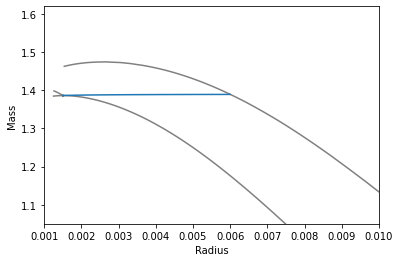

In [24]:
plt.plot(Rstawd_kep*Rdim/Rsun, Mdim*Mstawd_kep, color="gray")
plt.plot(Rrotwd_kep*Rdim/Rsun, Mdim*Mrotwd_kep, color="gray")
plt.plot(Rrotwd_seq*Rdim/Rsun, Mdim*Mrotwd_seq, color="gray")


plt.plot(Rrotwd_eq*Rdim/Rsun, Mrotwd*Mdim) 

plt.xlabel("Radius")
plt.ylabel("Mass")

plt.ylim(1.05,1.62)
plt.xlim(0.001,0.01)

In [25]:
Masswd0 = 1.39

Kep_Omega = interp1d( Mrotwd_kep*Mdim , Omegawd_kep )
Kep_Req   = interp1d( Mrotwd_kep*Mdim ,  Rrotwd_kep )
Kep_j     = interp1d( Mrotwd_kep*Mdim ,  Jwd_kep/JJdim )

#Omegawd_0 = Kep_Omega(Masswd0)
#Reqwd_0   = Kep_Req(Masswd0)
#jwd_0     = Kep_j(Masswd0)

Omegawd_0 = Omegawd[0]
Reqwd_0   = (1.0/3.0)*(Rrotwd_pol[0]+2.0*Rrotwd_eq[0])
jwd_0     = Jwd[0]
rhowd_0   = rhowd[0]


print("The star stars at the keplerian sequence with Mass0 = ", Masswd0, " Msun \tOmega0 = ", Omegawd_0*Rdim/c, " \t Req0 = ", Reqwd_0*Rdim/Rsun)

Req_j    = interp1d( Jwd / JJdim ,  Reqwd / Reqwd_0 , kind='linear' ) # Radius as function of angular momentum
Omega_j  = interp1d( Jwd / JJdim , Omegawd / Omegawd_0,kind='linear' ) # Angular velocity as function of angular momentum
rho_j    = interp1d( Jwd / JJdim , rhowd ,kind='linear' )              # central density as function of angular momentum

DrhoDj_dats = fit_derivative( Jwd / JJdim , rhowd )
Drho_dj     = interp1d( Jwd / JJdim , DrhoDj_dats ,kind='linear' ) # Derivative of density


The star stars at the keplerian sequence with Mass0 =  1.39  Msun 	Omega0 =  1504.6949277023548  	 Req0 =  0.0054665637976952525


In [26]:
def muWD(Bs,Rwd):
    #magnetic moment WD
    return Bs*np.power(Rwd,3.0)

def TdipIII(R_wd,Omega_wd):
    return np.power(R_wd,6.0) * np.power(Omega_wd,3.0)

def AdipIII(tau,Omegawd_0,Rwd_0,Jwd_0,Bs):
    return (1.0/(3.0*c**3)) * (1.0 + np.sin(np.pi*0.5)**2) * np.power(Omegawd_0,3.0) * np.power(muWD(Bs,Rwd_0),2.0) * tau  / Jwd_0

def Torque_dip(t,y,ffx):
    AAdip = ffx[0]
    cc    = ffx[1]
    #tau   = ffx[2]
   
    Reqx   = Req_j(y[0])
    Omegax = Omega_j(y[0])
    
    if cc==0:
        ec1 = -np.log(10.0) * np.power(10.0,t) * AAdip * TdipIII(Reqx,Omegax)
    else:
        BB = 1.0 / Reqx
        ec1 = -np.log(10.0) * np.power(10.0,t) * AAdip * TdipIII(Reqx,Omegax) * BB**4
        
    
    return np.array([ec1])

def RungheKut(t,y,h,fx):
    dsy1 = Torque_dip(t,y,fx)
    #print dsy1
    dsy2 = Torque_dip( t+h/2.0 , y + dsy1[0] * h / 2.0 , fx )
    #print dsy2
    dsy3 = Torque_dip( t + h / 2.0 , y + dsy2[0] * h / 2.0 , fx )
    #print dsy3
    dsy4 = Torque_dip( t + h  , y + dsy3[0] * h , fx )
    #print dsy4
    jnew = y[0] + 1.0/6.0 * h * ( dsy1[0] + 2.0 * ( dsy2[0] + dsy3[0] ) + dsy4[0] )
    return [ jnew ]



In [27]:
Bs0  = 1e6
jwd_dim = jwd_0*JJdim*Rdim**2/Jdim
tauD = 1.0 / AdipIII(1.0,Omegawd_0,Reqwd_0, jwd_dim , Bs0)
A0   = AdipIII(tauD, Omegawd_0, Reqwd_0, jwd_dim , Bs0) 


i = 0; #yy = [ Jwd[0]/JJdim ]
t0 = 1e-4
dt = 1e-2
yy = [[t0, Jwd[0]/JJdim]]

while rho_j(yy[i][1])<rhobeta and yy[i][1] > 1.01*Jwd[-1] / JJdim:
    yynew = RungheKut( t0+i*dt, [yy[i][1]], dt, [A0,0])
    #print(yynew)   
    i+=1
    yy.append( [t0+i*dt,yynew[0]] )
    
print(yy[-1])

[2.5501000000000005, np.float64(0.017977432267036145)]


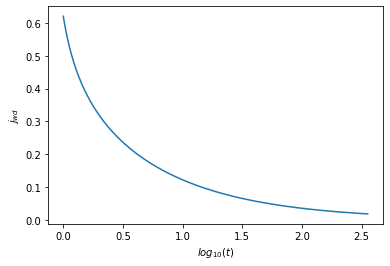

In [28]:
plt.plot( [ (t0+i*dt) for i in range(len(yy))], np.array(yy)[:,1] )

plt.ylabel("$j_{wd}$")
plt.xlabel("$log_{10}(t$)")

plt.show()

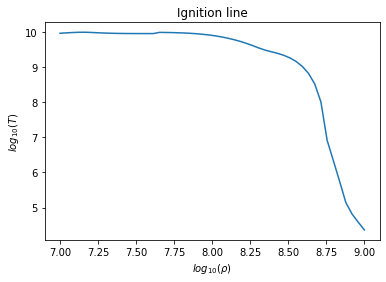

In [29]:
#---cabon-ignition line--------
def tauCC(rhox,Txi,Abar,Zbar,XC):
    T = np.power(10.0,Txi)
    rho = np.power(10.0, rhox)
    return np.log10( nunu.QnuTotal(rho,T,Abar,Zbar) / eCC.QCC(rho,T,Zbar,Abar,XC) )

def funcCC(T,rhox):
  #  T = np.power(10.0,Txi)
    rho = np.power( 10.0 , rhox )
    return eCC.QCC(rho,T,6.0,12.0,0.5)


############ Ignition line------------
Tx = np.linspace( 7.0, 9.0, 50)
NN = len(Tx)
rhoCC = np.zeros(NN)

i=0
for xx in Tx:
    Tc = brentq(tauCC , 2.0 , 10.0 ,args=(xx,12.0,6.0,0.5))
    rhoCC[i] = Tc
    i+=1


fig= plt.figure()
plt.plot(Tx,rhoCC)

plt.xlabel("$log_{10}(\\rho)$")
plt.ylabel("$log_{10}(T)$")

plt.title("Ignition line")

plt.show()

In [30]:
xmass  = np.array( [0.5] )
aion   = np.array( [12.0] )
zion   = np.array( [6.0] )

rhoi     = 1e7
Tpon_dat = np.linspace(4.0,10.0,50)
NN = len(Tpon_dat)
cv_dat = np.zeros(NN)


Cvion = np.zeros(NN)
Cve = np.zeros(NN)
Cvie = np.zeros(NN)
Cvii = np.zeros(NN)

Cvee = np.zeros(NN)

i=0
for ti in Tpon_dat:
    Ti = np.power(10.0,ti)
    cv_dat[i] = cv.cv_gas(rhoi,Ti,aion,xmass,zion)
    
    Ai = aion[0]
    Zi = zion[0]
    tr = kappaB*Ti/(me*c**2)

    Cve[i] = EOS.Cvienm(Ai,Zi,rhoi,tr)
    Cvion[i] = EOS.cv_ion()    
    
    Cvie[i] = ionee.Cvie(Ai,Zi,rhoi, Ti)
    Cvii[i] = ion.Cvii(Ai,Zi,rhoi,Ti) 
    Cvee[i] = ee.Cveenr(Ai,Zi,rhoi, Ti)
   
    i+=1


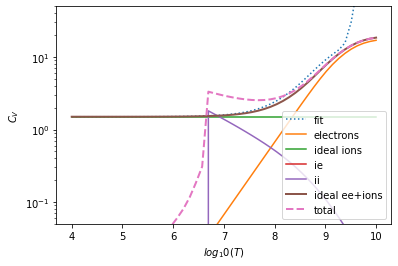

In [31]:
fig= plt.figure(figsize=(8,5))

plt.plot( Tpon_dat, cv_dat, ls=":",label="fit")
plt.plot( Tpon_dat, Cve , label="electrons")
plt.plot( Tpon_dat, Cvion , label="ideal ions")
plt.plot(  Tpon_dat, Cvie, label="ie" )
plt.plot( Tpon_dat, Cvii, label="ii" )

plt.semilogy(  Tpon_dat,   Cvion + Cve , lw=2,label="ideal ee+ions" )
plt.semilogy(  Tpon_dat,  Cvii + Cvie + Cvion + Cve , lw=2,ls="--", label="total" )


plt.ylim(0.5e-1,5e1)

plt.xlabel("$log_10(T)$")
plt.ylabel("$C_V $")

plt.legend()

plt.show()

In [32]:
def cv_gas(A,Z,rho,T):
    
    tr = kappaB*T/(me*c**2)

    Cve = EOS.Cvienm(A,Z,rho,tr)[0]
    Cvion = EOS.cv_ion()    
    
    Cvie = ionee.Cvie(A,Z,rho, T)
    Cvii = ion.Cvii(A,Z,rho,T)[0]
    Cvee = ee.Cveenr(A,Z,rho, T)
    
    return Cve + Cvion
  
def Torque_dip(t,y,ffx):
    
    AAdip = ffx[0]
    cc    = ffx[1]
    tau   = ffx[2]
   
    #average atomic weight and charge
    ration = ( xmass / aion ).sum()
    XmassT = ( xmass * zion / aion ).sum()   
    abar   = 1.0e0 / ration
    zbar   = abar * XmassT

    Twd = Tdim*y[1]
   
    #Reqx   = Interp1D_ll( y[0], [ Jwd[j] / JJdim for j in range(NN)] , [ (1.0/3.0)*(Rrotwd_pol[j]+2.0*Rrotwd_eq[j])  / Reqwd_0  for j in range(NN)] )
    #Omegax = Interp1D_ll( y[0], [ Jwd[j] / JJdim for j in range(NN)] , [ Omegawd[j] / Omegawd_0 for j in range(NN)] )
    Reqx      = Req_j(y[0])
    Omegax    = Omega_j(y[0])
    drhodj    =  Drho_dj(y[0]) #Interp1D_ll( y[0], [ Jwd[j] / JJdim for j in range(NN)] , DrhoDj_dats )
    logrhowdx =  rho_j(y[0]) #Interp1D_ll( y[0], [ Jwd[j] / JJdim for j in range(NN)] , [ rhowd[j]  for j in range(NN)] )
    rhowd     = np.power(10.0, logrhowdx)
    
    if cc==0:
        ec1 = -np.log(10.0) * np.power(10.0,t) * AAdip * TdipIII(Reqx,Omegax)
    else:
        BB  = 1.0 / Reqx
        ec1 = -np.log(10.0) * np.power(10.0,t) * AAdip * TdipIII(Reqx,Omegax) * BB**4
        
    
    cvv   = cv_gas( aion,zion, rhowd, Twd )
    qnunu = nunu.QnuTotal( rhowd, Twd, abar, zbar )
    qCC   = eCC.QCC( rhowd, Twd, zbar, abar, xmass[0] )
    
    
    ec2 = y[1] * drhodj * np.log(10.0) * ec1 / cvv + np.log(10.0) * np.power(10.0,t) * tau * abar * mu * (-qnunu + qCC )/( rhowd * kappaB * Tdim * cvv )
    
    return np.array( [ ec1, ec2 ] )

Torque_dip(-5.0,[ Jwd[0]/JJdim, 1e8/Tdim ] ,[A0,0.0,tauD])

def Terms_eqs(t,y,ffx):
    AAdip = ffx[0]
    cc    = ffx[1]
    tau   = ffx[2]
    
    #average atomic weight and charge
    ration = ( xmass / aion ).sum()
    XmassT = ( xmass * zion / aion ).sum()   
    abar   = 1.0e0 / ration
    zbar   = abar * XmassT
        
    Reqx   = Req_j(y[0])
    Omegax = Omega_j(y[0])
    drhodj =  Drho_dj(y[0]) #Interp1D_ll( y[0], [ Jwd[j] / JJdim for j in range(NN)] , DrhoDj_dats )
    rhowdx =  rho_j(y[0])

    #Reqx = Interp1D_ll( y[0], [ Jwd[j] / JJdim for j in range(NN)] , [ (1.0/3.0)*(Rrotwd_pol[j]+2.0*Rrotwd_eq[j])  / Reqwd_0  for j in range(NN)] )
    #Omegax = Interp1D_ll( y[0], [ Jwd[j] / JJdim for j in range(NN)] , [ Omegawd[j] / Omegawd_0 for j in range(NN)] )
    #drhodj =  Interp1D_ll( y[0], [ Jwd[j] / JJdim for j in range(NN)] , DrhoDj_dats )
    #rhowdx =  Interp1D_ll( y[0], [ Jwd[j] / JJdim for j in range(NN)] , [ rhowd[j]  for j in range(NN)] )

    if cc==0:
        ec1 = -np.log(10.0)*np.power(10.0,t)*AAdip*TdipIII(Reqx,Omegax)
    else:
        BB = 1.0 / Reqx
        ec1 =  -np.log(10.0)*np.power(10.0,t)*AAdip*TdipIII(Reqx,Omegax) * BB**4
       
    #ec2 = y[1] * drhodj * np.log(10.0) * ec1 / cv_gas( np.power(10.0,rhowdx), Tdim*y[1], aion, xmass,zion)
    
    cvv   = cv_gas( aion,zion,  np.power(10.0,rhowdx), Tdim*y[1])
 
    term1 =  drhodj * np.log(10.0) * ec1 / cvv 
    term2 = np.log(10.0) * np.power(10.0,t) * tau * abar * mu * (  eCC.QCC(np.power(10.0,rhowdx),Tdim*y[1],zbar,abar,xmass[0])-nunu.QnuTotal(np.power(10.0,rhowdx),Tdim * y[1],abar,zbar)) / ( np.power(10.0,rhowdx) * kappaB * y[1] * Tdim * cvv )
    
    #print abar,zbar, term2, eCC.QCC(np.power(10.0,rhowdx),Tdim*y[1],zbar,abar,xmass[0]) , nunu.QnuTotal(np.power(10.0,rhowdx),Tdim * y[1],abar,zbar)
    #print cvv, kappa*y[1]*Tdim,  np.log(10.0) * np.power(10.0,t) * tau * abar * mu , np.power(10.0,rhowdx)
    return np.array([term1,term2])

def RungheKut(t,y,h,fx):
    dsy1 = Torque_dip(t,y,fx)
    #print dsy1
    dsy2 = Torque_dip( t+h/2.0 , y + dsy1[0] * h / 2.0 , fx )
    #print dsy2
    dsy3 = Torque_dip( t + h / 2.0 , y + dsy2[0] * h / 2.0 , fx )
    #print dsy3
    dsy4 = Torque_dip( t + h  , y + dsy3[0] * h , fx )
    #print dsy4
    jnew = y[0] + 1.0/6.0 * h * ( dsy1[0] + 2.0 * ( dsy2[0] + dsy3[0] ) + dsy4[0] )
    return [ jnew ]


In [33]:



def Tevolution(jwd0,rhowd0,T0,cc):
   
    yy     = [ jwd0, T0/Tdim]   
    rho_x  = rhowd0
    
    t0       = -5.0
    dt       = 1e-6
    epsilon0 = 1e-5
    evol_1   = [ [ np.power(10.0,t0)*tauD, rho_x, yy[0], Omegawd_0, T0/Tdim, Reqwd_0 ] ]
    
    i=1
    incr2 = 0
    
    print( "Comparing density wiht ignition density:", rho_x, Interp1D_ld(np.log10(yy[1]*Tdim),Tx,rhoCC) )
    
    tnow = t0
    while rho_x < rhobeta and rho_x<2.4*Interp1D_ld(np.log10(yy[1]*Tdim),Tx,rhoCC):
        
        tnew    = tnow + dt
        yynew_1 = RungheKut(tnew, yy,dt,[A0,cc,tauD])
        yyint   = RungheKut(tnow + 0.5*dt , yy, 0.5 * dt ,[A0,cc,tauD])
        yynew_2 = RungheKut(tnow + dt , yyint , 0.5 * dt ,[A0,cc,tauD])
        
        epsilon = []; delta =[]
        incr = 0
        for j in range(len(yynew_1)):
            epsilon.append( 1.0/15.0*abs(yynew_1[j]-yynew_2[j]) )
            
        for j in range(len(epsilon)):
            if epsilon[j]<epsilon0:
                delta.append( 0.8 * dt * np.power(epsilon0/epsilon[j],1.0/4.0+1.0) )
                incr+=1
            else:
                delta.append( 0.8 * dt * np.power(epsilon0/epsilon[j],1.0/4.0) )
       
        if incr<len(epsilon) and incr2<10:
            dt *= 0.5
            incr2+=1
        else: 
            yy        = yynew_1
            Reqnew    = Req_j(yy[0])
            Omegaxnew = Omega_j(yy[0])
            rho_x     = rho_j(yy[0])
            #Omegaxnew = Interp1D_ll( yy[0], [ Jwd[j] / JJdim for j in range(NN)] , [ Omegawd[j] / Omegawd_0 for j in range(NN)] )
            #Reqnew = Interp1D_ll( yy[0], [ Jwd[j] / JJdim for j in range(NN)] , [  (1.0/3.0)*(Rrotwd_pol[j]+2.0*Rrotwd_eq[j])  / Reqwd_0  for j in range(NN)] )
            #rho_x = Interp1D_ll( yy[0], [ Jwd[j] / JJdim for j in range(NN)] , [ rhowd[j]  for j in range(NN)] )
            delta_time = tnew-tnow
            termss = Terms_eqs(tnew,yy,[A0, cc, tauD])
            evol_1.append([ np.power(10.0,(tnew))*tauD , rho_x ,yy[0] , Omegawd_0 * Omegaxnew , yy[1], Reqnew * Reqwd_0,termss[0]*delta_time,termss[1]*delta_time])
           
            i=i+1
            tnow = tnew
            
            if max(epsilon)/epsilon0<1e-3:
                dt = min(2.0*dt,1e-2)
        #print dt

    
    return evol_1

Temperature = ode(Torque_dip).set_integrator('dopri5',atol=1e-9)
def Tevolution_2( y0, drr, rhowd0, Bs, cc):
    
    T0     = y0[1]*Tdim
    tauD   = 1.0 / AdipIII(1.0,Omegawd_0*c/Rdim,Reqwd_0*Rdim,jwd_0*JJdim*Rdim**2/Jdim,Bs)
    A0     = AdipIII(tauD, Omegawd_0*c/Rdim, Reqwd_0*Rdim,Jadim,Bs)

    t0     = -3.0
    rho_x  = rhowd0
    evol_1 = [ [np.power(10.0,t0)*tauD, rho_x, y0[0], Omegawd_0, y0[1] , Reqwd_0,0.0,0.0] ]
    i=1

    print( "Comparing density wiht ignition density:", rho_x, Interp1D_ld(np.log10(y0[1]*Tdim),Tx,rhoCC) )
    
    Temperature.set_initial_value( y0,t0 ).set_f_params([A0, cc, tauD])
    while Temperature.successful() and  rho_x<rhobeta and rho_x<Interp1D_ld(np.log10(Temperature.y[1]*Tdim),Tx,rhoCC):
        told = Temperature.t
        Temperature.integrate(Temperature.t+drr)

        ywd = Temperature.y[0]
        Reqnew    = Req_j(ywd)
        Omegaxnew = Omega_j(ywd)
        rho_x     = rho_j(ywd)
        #rho_x = Interp1D_ll( Temperature.y[0], [ Jwd[j] / JJdim for j in range(NN)] , [ rhowd[j]  for j in range(NN)] )
        #Omegaxnew = Interp1D_ll( Temperature.y[0], [ Jwd[j] / JJdim for j in range(NN)] , [ Omegawd[j] / Omegawd_0 for j in range(NN)] )
        #Reqnew = Interp1D_ll( Temperature.y[0], [ Jwd[j] / JJdim for j in range(NN)] , [  (1.0/3.0)*(Rrotwd_pol[j]+2.0*Rrotwd_eq[j])  / Reqwd_0 for j in range(NN)] )
   
        delta_time = Temperature.t - told
        termss = Terms_eqs(Temperature.t,Temperature.y,[A0, cc, tauD])
      
        evol_1.append( [ np.power(10.0,(Temperature.t))*tauD , rho_x ,Temperature.y[0] , Omegawd_0 * Omegaxnew , Temperature.y[1], Reqnew * Reqwd_0,termss[0]*delta_time,termss[1]*delta_time])
        
        print(ywd, rho_x, np.log10(Temperature.y[1]*Tdim), Interp1D_ld(np.log10(Temperature.y[1]*Tdim),Tx,rhoCC) )
    
    return evol_1

In [34]:
x_B = np.linspace(8,10,10)

Bs0  = np.power(10.0,x_B[0])
tauD = 1.0 / AdipIII( 1.0, Omegawd_0*c/Rdim, Reqwd_0*Rdim, jwd_0*JJdim*Rdim**2/Jdim , Bs0)
A0   = AdipIII( tauD, Omegawd_0*c/Rdim, Reqwd_0*Rdim, Jadim,Bs0 )
    
Evol1 = Tevolution_2( [ Jwd[0]/JJdim, 1e8/Tdim ] , 1e0, rhowd_0, Bs0 , 0.0 )

Comparing density wiht ignition density: 8.4458981 9.895844090151794
0.620827366014555 8.445898100000004 8.000000000000002 9.895844090151792
0.6208273660145388 8.445898100000033 8.00000000000002 9.895844090151781
0.6208273660143763 8.445898100000331 8.000000000000194 9.895844090151677
0.6208273660127511 8.44589810000331 8.000000000001934 9.895844090150629
0.6208273659964991 8.445898100033101 8.000000000019345 9.895844090140141
0.6208273658339795 8.445898100331014 8.000000000193454 9.895844090035256
0.6208273642087833 8.445898103310132 8.000000001934549 9.895844088986422
0.6208273479568218 8.445898133101304 8.000000019345494 9.89584407849807
0.6208271854372909 8.445898431012886 8.000000193454866 9.89584397361461
0.6208255602503198 8.44590141011342 8.000001934540169 9.89584292478509
0.6208093092144471 8.44593119959027 8.000019344550806 9.895832436997333
0.6206468821912449 8.446228941597932 8.000193360469721 9.895727609834271
0.6190309539030953 8.449191070209704 8.001925092538935 9.894684

Text(0, 0.5, 'time')

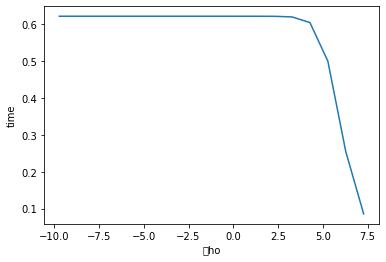

In [36]:
plt.plot( np.log10(np.array(Evol1)[:,0]/yr), np.array(Evol1)[:,2])

plt.xlabel("\rho")
plt.ylabel("time")